In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('amazonreviews.tsv',sep='\t')
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [5]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [6]:
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates()
print("Rows after removing duplicates:",len(df))

Duplicates: 0
Rows after removing duplicates: 10000


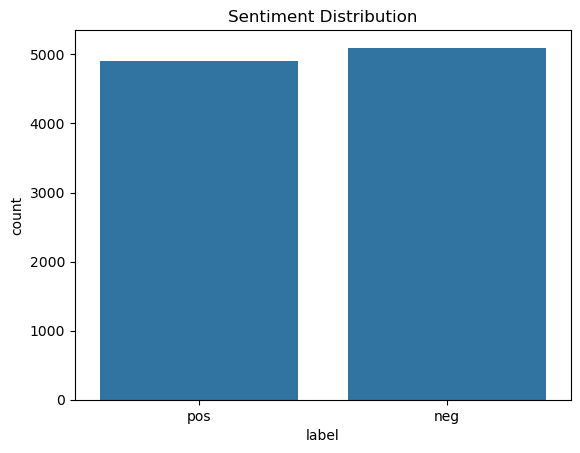

In [7]:
sns.countplot(x='label',data=df)
plt.title('Sentiment Distribution')
plt.show()

In [9]:
#small letters all reviews
df['review']=df['review'].str.lower()
df.head()

,label,review
0,pos,stuning even for the non-gamer: this sound tra...
1,pos,the best soundtrack ever to anything.: i'm rea...
2,pos,amazing!: this soundtrack is my favorite music...
3,pos,excellent soundtrack: i truly like this soundt...
4,pos,"remember, pull your jaw off the floor after he..."


In [12]:
from wordcloud import WordCloud

In [11]:
!pip install wordcloud

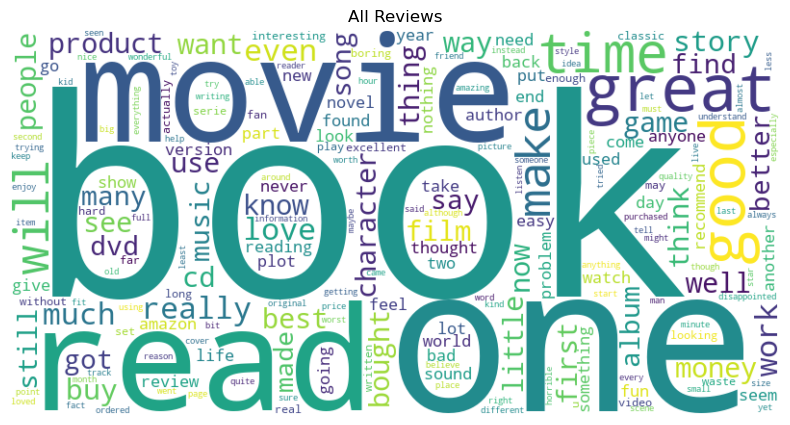

In [13]:
wc=WordCloud(width=800,height=400,background_color='white')
wc.generate(' '.join(df['review']))
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('All Reviews')
plt.show()

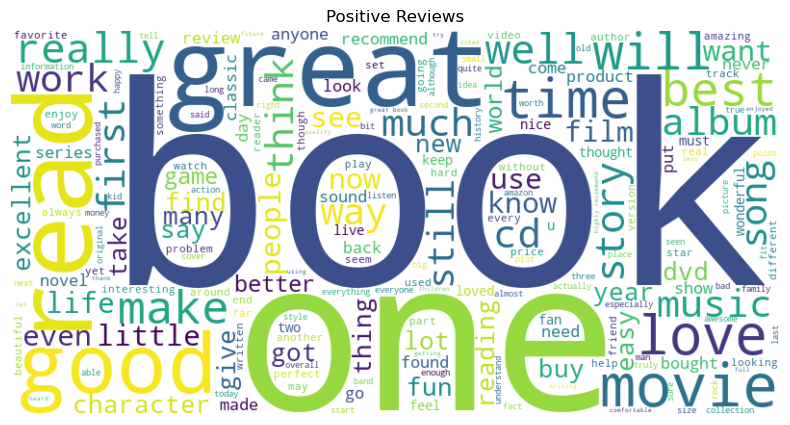

In [14]:
# positive reviews word cloud
wc_pos=WordCloud(width=800,height=400,background_color='white')
wc_pos.generate(' '.join(df[df['label']=='pos']['review']))
plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews')
plt.show()

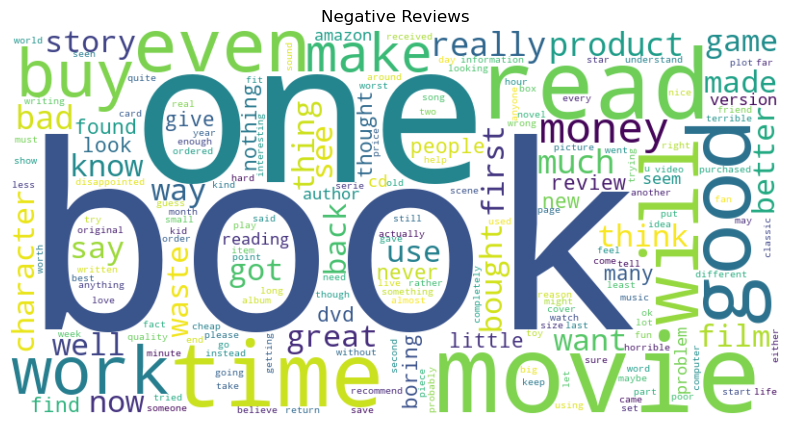

In [15]:
# negative reviews word cloud
wc_neg=WordCloud(width=800,height=400,background_color='white')
wc_neg.generate(' '.join(df[df['label']=='neg']['review']))
plt.figure(figsize=(10,5))
plt.imshow(wc_neg,interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews')
plt.show()

In [16]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [18]:
stop_words=set(stopwords.words('english'))

In [19]:
def preprocess(text):
    tokens=word_tokenize(str(text))
    return [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]

In [20]:
df['tokens']=df['review'].apply(preprocess)
df[['review','tokens']].head()

,review,tokens
0,stuning even for the non-gamer: this sound tra...,"[stuning, even, sound, track, beautiful, paint..."
1,the best soundtrack ever to anything.: i'm rea...,"[best, soundtrack, ever, anything, reading, lo..."
2,amazing!: this soundtrack is my favorite music...,"[amazing, soundtrack, favorite, music, time, h..."
3,excellent soundtrack: i truly like this soundt...,"[excellent, soundtrack, truly, like, soundtrac..."
4,"remember, pull your jaw off the floor after he...","[remember, pull, jaw, floor, hearing, played, ..."


In [21]:
from collections import Counter

In [22]:
pos_words=[w for tokens in df[df['label']=='pos']['tokens'] for w in tokens]
neg_words=[w for tokens in df[df['label']=='neg']['tokens'] for w in tokens]

In [23]:
print("Top 20 positive words:")
print(Counter(pos_words).most_common(20))

Top 20 positive words:
[('book', 3345), ('great', 2102), ('one', 1863), ('good', 1644), ('read', 1563), ('like', 1275), ('movie', 1093), ('would', 1002), ('love', 906), ('time', 886), ('well', 853), ('really', 829), ('best', 805), ('get', 797), ('story', 720), ('first', 711), ('much', 653), ('cd', 606), ('music', 564), ('also', 562)]


In [24]:
print("\nTop 20 negative words:")
print(Counter(neg_words).most_common(20))


Top 20 negative words:
[('book', 3223), ('one', 2040), ('would', 1600), ('like', 1553), ('movie', 1488), ('read', 1196), ('good', 1144), ('get', 1144), ('time', 1043), ('even', 904), ('could', 880), ('buy', 817), ('really', 782), ('much', 773), ('bad', 753), ('money', 751), ('first', 744), ('better', 660), ('great', 636), ('product', 625)]


# Model Development

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [27]:
df['clean']=df['tokens'].apply(lambda x: ' '.join(x))

In [28]:
X_train,X_test,y_train,y_test=train_test_split(df['clean'],df['label'],test_size=0.2,random_state=42)

In [29]:
tfidf=TfidfVectorizer()
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [30]:
print("Train:",X_train_tfidf.shape,"| Test:",X_test_tfidf.shape)

Train: (8000, 26316) | Test: (2000, 26316)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
lr=LogisticRegression(solver='liblinear',random_state=42)
lr.fit(X_train_tfidf,y_train)
y_pred_lr=lr.predict(X_test_tfidf)

In [33]:
print("Logistic Regression:")
print(classification_report(y_test,y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1037
         pos       0.84      0.85      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [34]:
from sklearn.svm import SVC

In [35]:
svm=SVC(kernel='linear',random_state=42)
svm.fit(X_train_tfidf,y_train)
y_pred_svm=svm.predict(X_test_tfidf)

In [36]:
print("SVM:")
print(classification_report(y_test,y_pred_svm))

SVM:
              precision    recall  f1-score   support

         neg       0.86      0.85      0.85      1037
         pos       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



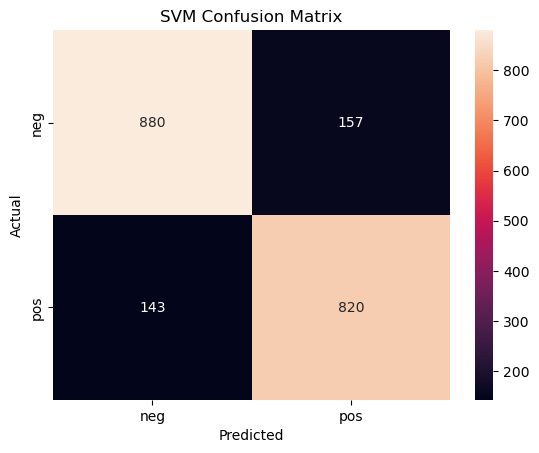

In [37]:
# confusion matrix for SVM
cm=confusion_matrix(y_test,y_pred_svm)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['neg','pos'],yticklabels=['neg','pos'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
import gensim.downloader as api
import numpy as np

In [42]:
!pip install gensim

In [43]:
w2v=api.load('glove-wiki-gigaword-100')

[==================================================] 100.0% 128.1/128.1MB downloaded


In [44]:
def get_embedding(tokens):
    vecs=[w2v[w] for w in tokens if w in w2v.key_to_index]
    return np.mean(vecs,axis=0) if vecs else np.zeros(100)


In [45]:
X_w2v=np.array(df['tokens'].apply(get_embedding).tolist())
print("Word2Vec features shape:",X_w2v.shape)

Word2Vec features shape: (10000, 100)


In [46]:
from sklearn.preprocessing import LabelEncoder

In [47]:
le=LabelEncoder()
y_enc=le.fit_transform(df['label'])

In [48]:
X_train_w2v,X_test_w2v,y_train_w2v,y_test_w2v=train_test_split(X_w2v,y_enc,test_size=0.2,random_state=42)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [50]:
nn=Sequential([
    Dense(128,activation='relu',input_shape=(100,)),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])
nn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
nn.summary()

C:\Users\shiva\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
nn.fit(X_train_w2v,y_train_w2v,epochs=10,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6650 - loss: 0.6096 - val_accuracy: 0.7725 - val_loss: 0.5168
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7522 - loss: 0.5129 - val_accuracy: 0.7806 - val_loss: 0.4764
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7623 - loss: 0.4910 - val_accuracy: 0.7844 - val_loss: 0.4664
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7684 - loss: 0.4777 - val_accuracy: 0.7763 - val_loss: 0.4716
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7753 - loss: 0.4696 - val_accuracy: 0.7862 - val_loss: 0.4605
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7822 - loss: 0.4650 - val_accuracy: 0.7875 - val_loss: 0.4544
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7805 - loss: 0.4587 - val_accuracy: 0.7881 - val_loss: 0.4579
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7834 - loss: 0.4575 - val_accuracy: 0.

In [52]:
y_pred_nn=(nn.predict(X_test_w2v)>0.5).astype(int)
y_pred_nn_labels=le.inverse_transform(y_pred_nn.flatten())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [53]:
print("Neural Network (Word2Vec):")
print(classification_report(le.inverse_transform(y_test_w2v),y_pred_nn_labels))

Neural Network (Word2Vec):
              precision    recall  f1-score   support

         neg       0.81      0.79      0.80      1037
         pos       0.78      0.80      0.79       963

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



# Validation — Cross Validation

In [54]:
from sklearn.model_selection import StratifiedKFold

In [55]:
kf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
acc,prec,rec,f1=[],[],[],[]

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [57]:
for train_i,val_i in kf.split(X_train_tfidf,y_train):
    X_tr=X_train_tfidf[train_i]
    X_val=X_train_tfidf[val_i]



    

    y_tr=y_train.iloc[train_i]
    y_val=y_train.iloc[val_i]

    lr.fit(X_tr,y_tr)

    y_pred=lr.predict(X_val)

    
    acc.append(accuracy_score(y_val,y_pred))
    prec.append(precision_score(y_val,y_pred,pos_label='pos'))
    rec.append(recall_score(y_val,y_pred,pos_label='pos'))
    f1.append(f1_score(y_val,y_pred,pos_label='pos'))

In [58]:
print("LR CV Results")

print(np.mean(acc), np.mean(prec), np.mean(rec), np.mean(f1))

LR CV Results
0.8547499999999999 0.8515060667422871 0.8540609137055837 0.852752366526657


In [59]:
compare=pd.DataFrame({'Model': ['LR','SVM','NN'],'Accuracy': [accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_svm),accuracy_score(le.inverse_transform(y_test_w2v),y_pred_nn_labels)]})
compare

,Model,Accuracy
0,LR,0.8500
1,SVM,0.8500
2,NN,0.7955


# LR and SVM are giving good results.
# NN with Word2Vec is okay but needs more data.
# SVM + TF-IDF looks best here.

# Cross-validation shows LR results are consistent.
# Low std means model is stable and not overfitting much.